<a href="https://colab.research.google.com/github/EugOT/CN-pr-Allen-Brain/blob/main/redl_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

installing dependencies

In [6]:
# @title Install packages
!pip install pip --upgrade --quiet
!pip install brain_observatory_utilities --upgrade --quiet
!pip install pandas --quiet
!pip install seaborn --quiet

Import packages

In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import brain_observatory_utilities.datasets.optical_physiology.data_formatting as ophys_formatting
import brain_observatory_utilities.utilities.general_utilities as utilities

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

pd.set_option('display.max_columns', 500)

Load Dataset

In [8]:
# read data from cache
# or download if necessary

data_storage_directory = "./tmp"  # Note: this path must exist on your local drive
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=data_storage_directory)

session_table = cache.get_ophys_session_table()
experiment_table = cache.get_ophys_experiment_table()

/usr/local/lib/python3.10/dist-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [15]:
print (cache)
session_table.head()


,behavior_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,project_code,session_type,session_number,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,ophys_experiment_id
ophys_session_id,,,,,,,,,,,,,,,,,,,
951410079,951520319,"[1018028360, 1018028345, 1018028357, 101802834...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,VisualBehaviorMultiscope,OPHYS_1_images_A,1,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,"[951980471, 951980473, 951980475, 951980479, 9..."
952430817,952554548,"[1018028357, 1018028345, 1018028339, 1018028354]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,209,VisualBehaviorMultiscope,OPHYS_2_images_A_passive,2,0,66,1,2019-09-23 08:13:07.627573+00:00,MESO.1,"[953659743, 953659745, 953659749, 953659752]"
954954402,953982960,"[1018028360, 1018028342, 1018028357, 101802835...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,210,VisualBehaviorMultiscope,OPHYS_3_images_A,3,0,67,2,2019-09-24 16:00:00+00:00,MESO.1,"[958527464, 958527471, 958527474, 958527479, 9..."
955775716,956010809,"[1018028342, 1018028339, 1018028345]",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,212,VisualBehaviorMultiscope,OPHYS_3_images_A,3,1,68,3,2019-09-26 08:44:37.199778+00:00,MESO.1,"[956941841, 956941844, 956941846]"
957020350,957032492,"[1018028354, 1018028345, 1018028360, 101802834...",457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,213,VisualBehaviorMultiscope,OPHYS_4_images_B,4,0,0,4,2019-09-27 08:28:05.415005+00:00,MESO.1,"[957759562, 957759564, 957759566, 957759570, 9..."


In [16]:
experiment_table.head()

,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,project_code,session_type,session_number,image_set,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,
951980486,951520319,951410079,1018028360,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,300,VISl,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,False,Familiar,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,1085400869
951980473,951520319,951410079,1018028345,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISp,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,False,Familiar,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,1085400919
951980481,951520319,951410079,1018028357,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISl,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,False,Familiar,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,1085400972
951980471,951520319,951410079,1018028342,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISp,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,False,Familiar,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,1085394308
951980475,951520319,951410079,1018028339,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,75,VISp,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,False,Familiar,0,65,0,2019-09-20 09:45:29.897856+00:00,MESO.1,1085400920


In [19]:
ophys_session_id = 951410079
session_table.loc[ophys_session_id]

behavior_session_id                                                        951520319
ophys_container_id                 [1018028360, 1018028345, 1018028357, 101802834...
mouse_id                                                                      457841
indicator                                                                    GCaMP6f
full_genotype                          Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt
driver_line                                                           [Sst-IRES-Cre]
cre_line                                                                Sst-IRES-Cre
reporter_line                                             Ai148(TIT2L-GC6f-ICL-tTA2)
sex                                                                                F
age_in_days                                                                      206
project_code                                                VisualBehaviorMultiscope
session_type                                                     

In [20]:
experiments = {}
ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
for ophys_experiment_id in ophys_experiment_ids:
    experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)

behavior_ophys_experiment_951980471.nwb: 100%|██████████| 264M/264M [00:11<00:00, 23.7MMB/s]
/usr/local/lib/python3.10/dist-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.3.0 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/python3.10/dist-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.2.5 because version 2.6.0-alpha is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
behavior_ophys_experiment_951980473.nwb: 100%|██████████| 249M/249M [00:11<00:00, 22.6MMB/s]
/usr/local/lib/python3.10/dist-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.3.0 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/pytho

In [21]:
experiment = experiments[ophys_experiment_ids[1]]
experiment.cell_specimen_table.head()

,cell_roi_id,height,mask_image_plane,max_correction_down,max_correction_left,max_correction_right,max_correction_up,valid_roi,width,x,y,roi_mask
cell_specimen_id,,,,,,,,,,,,
1086620813,1080744295,17,0,4.0,22.0,3.0,30.0,True,17,293,395,"[[False, False, False, False, False, False, Fa..."
1086621290,1080744315,15,0,4.0,22.0,3.0,30.0,True,16,200,254,"[[False, False, False, False, False, False, Fa..."
1086621434,1080744321,16,0,4.0,22.0,3.0,30.0,True,14,413,247,"[[False, False, False, False, False, False, Fa..."
1086621629,1080744326,20,0,4.0,22.0,3.0,30.0,True,21,271,244,"[[False, False, False, False, False, False, Fa..."
1086621968,1080744337,21,0,4.0,22.0,3.0,30.0,True,16,129,204,"[[False, False, False, False, False, False, Fa..."


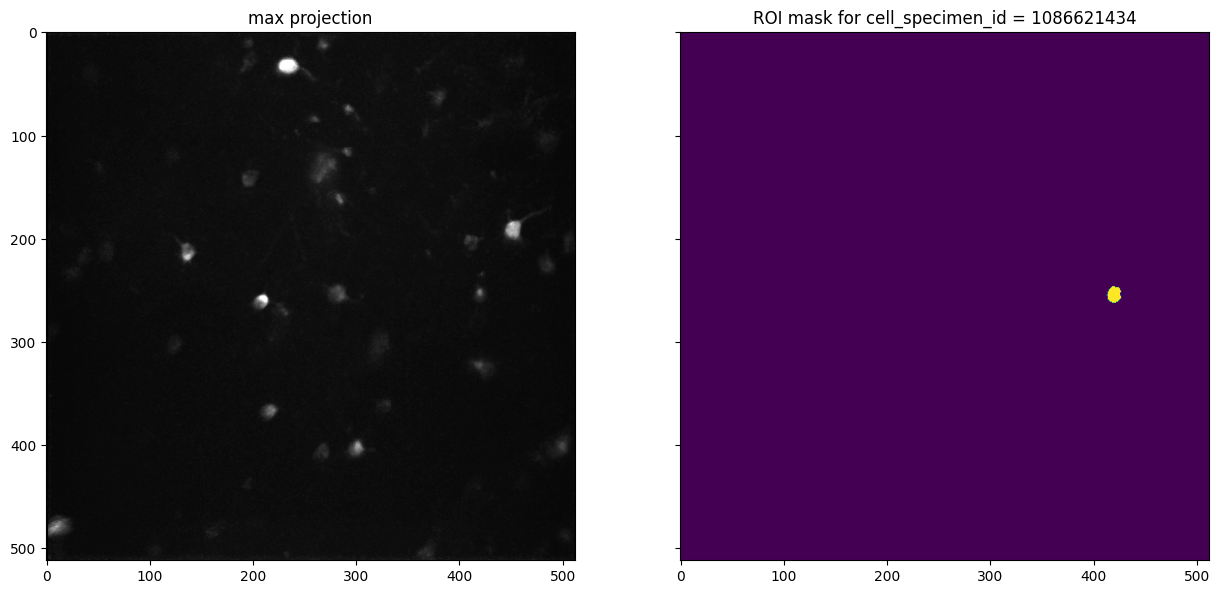

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)
ax[0].imshow(experiment.max_projection, cmap='gray')
ax[0].set_title('max projection')

cell_specimen_id = experiment.cell_specimen_table.index[2]
ax[1].imshow(experiment.cell_specimen_table.loc[cell_specimen_id]['roi_mask'])
ax[1].set_title('ROI mask for cell_specimen_id = {}'.format(cell_specimen_id))
fig.show()